## Section 1: Problem Framing

**Business Question**

What characteristics of a social media post predict whether it will generate donations, and what drives overall engagement? The organization posts sporadically across multiple platforms with no data-driven strategy. This pipeline gives them a model they can use before posting — input the planned post's characteristics and get a prediction of whether it will convert to donations.

**Two Models**

This notebook builds two models addressing different operational questions:

1. **Engagement Rate Regression** — predicts the numeric engagement rate a post will receive based on its characteristics. Uses Random Forest and Gradient Boosting regressors, evaluated by R² and RMSE.

2. **Donation Referral Classifier** — predicts whether a post will generate any donation referrals at all (binary: yes/no). Uses Random Forest and Gradient Boosting classifiers, evaluated by Recall and F1.

**Predictive vs. Explanatory**

Both models are primarily predictive — the goal is operational forecasting, not causal inference. However, feature importance rankings will be used to extract explanatory insight: which post characteristics most strongly predict performance.

**Success Metrics**

For the regression: R² above 0.5 indicates the model explains meaningful variance in engagement. For the classifier: Recall is the primary metric — missing a post that would have generated donations means lost revenue for the organization.

**Decisions This Model Can Inform**

- Which platform to post on for maximum donation conversion
- Whether to boost a post before publishing
- What time of day and day of week drives the most engagement
- Whether posts featuring resident stories outperform general content
- What content topics and sentiment tones generate donations vs. just likes

## Section 2: Data Loading

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

from data.loader import load_social_media_posts

posts_df = load_social_media_posts()
print("posts_df shape:", posts_df.shape)
posts_df.head()

Loaded 'social_media_posts' with 812 rows.
posts_df shape: (812, 39)


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00+00:00,Thursday,18.0,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21.0,10.0,21473.25,1522.0,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00+00:00,Friday,11.0,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335.0,2.0,4708.45,1833.0,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00+00:00,Sunday,10.0,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8.0,0.0,0.00,457.0,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00+00:00,Monday,15.0,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62.0,0.0,0.00,1796.0,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00+00:00,Monday,15.0,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172.0,2.0,8351.49,916.0,NaN,NaN,NaN,NaN


## Section 3: Feature Engineering

In [3]:
from features.social_features import build_social_features

social_df = build_social_features(posts_df)
print("social_df shape:", social_df.shape)
print(social_df[["engagement_rate", "made_donation_referral"]].head())
print("made_donation_referral distribution:")
print(social_df["made_donation_referral"].value_counts())

social_df shape: (812, 60)
   engagement_rate  made_donation_referral
0           0.1105                    True
1           0.1745                    True
2           0.1411                   False
3           0.0677                   False
4           0.0802                    True
made_donation_referral distribution:
made_donation_referral
True     522
False    290
Name: count, dtype: int64


## Section 4: Exploration

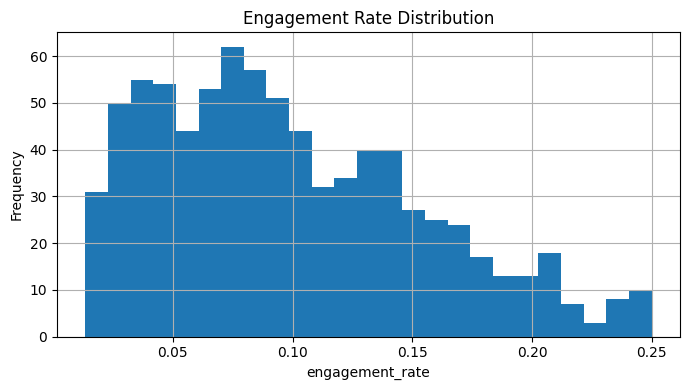

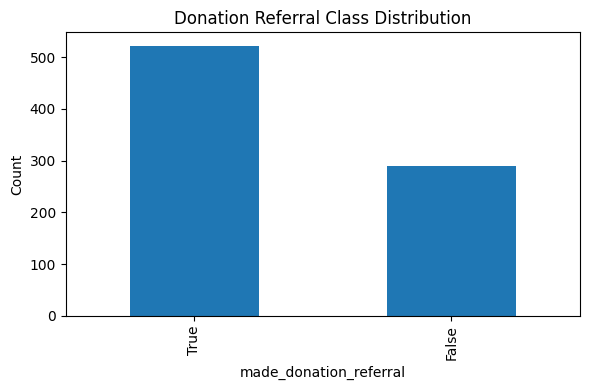

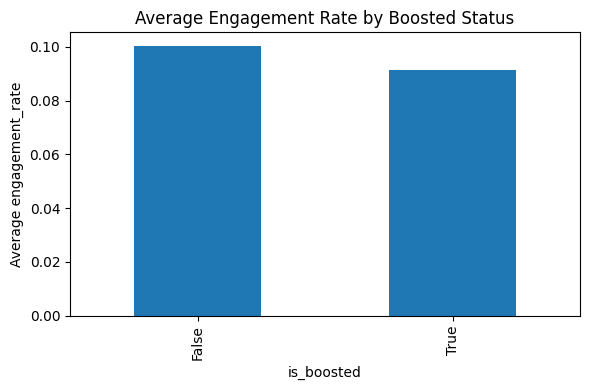

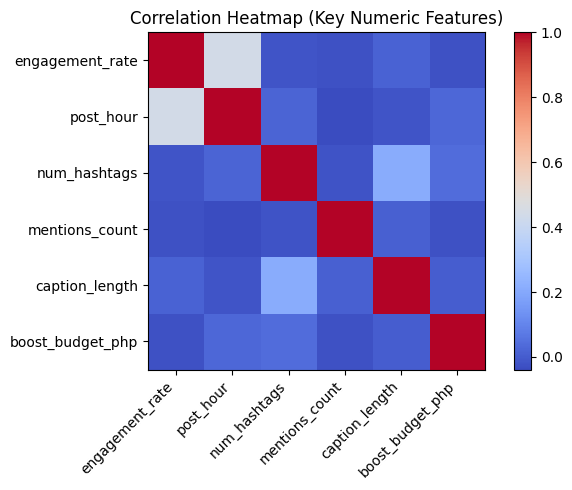

In [4]:
import matplotlib.pyplot as plt

# 1) Engagement rate distribution
plt.figure(figsize=(7, 4))
social_df["engagement_rate"].dropna().hist(bins=25)
plt.title("Engagement Rate Distribution")
plt.xlabel("engagement_rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2) Donation referral class distribution
plt.figure(figsize=(6, 4))
social_df["made_donation_referral"].value_counts().plot(kind="bar")
plt.title("Donation Referral Class Distribution")
plt.xlabel("made_donation_referral")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3) Engagement rate by boosted status
plt.figure(figsize=(6, 4))
social_df.groupby("is_boosted")["engagement_rate"].mean().plot(kind="bar")
plt.title("Average Engagement Rate by Boosted Status")
plt.xlabel("is_boosted")
plt.ylabel("Average engagement_rate")
plt.tight_layout()
plt.show()

# 4) Correlation among key numeric variables
corr_cols = [
    c
    for c in [
        "engagement_rate",
        "post_hour",
        "num_hashtags",
        "mentions_count",
        "caption_length",
        "boost_budget_php",
    ]
    if c in social_df.columns
]
if len(corr_cols) > 1:
    plt.figure(figsize=(7, 5))
    corr = social_df[corr_cols].corr()
    plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.title("Correlation Heatmap (Key Numeric Features)")
    plt.tight_layout()
    plt.show()

## Section 5: Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split

feature_df = social_df.copy()

X = feature_df.drop(columns=["engagement_rate", "made_donation_referral"], errors="ignore")
X = X.drop(
    columns=["created_at", "platform_post_id", "post_url", "caption", "hashtags"],
    errors="ignore",
)
X = X.fillna(0)

y_reg = feature_df["engagement_rate"].fillna(0)
y_clf = feature_df["made_donation_referral"].astype(bool)

# Regression split (engagement_rate)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42,
)

# Classification split (made_donation_referral)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf,
)

print("Regression split shapes:")
print(X_train_reg.shape, X_test_reg.shape, y_train_reg.shape, y_test_reg.shape)
print("\nClassification split shapes:")
print(X_train_clf.shape, X_test_clf.shape, y_train_clf.shape, y_test_clf.shape)

Regression split shapes:
(649, 58) (163, 58) (649,) (163,)

Classification split shapes:
(649, 58) (163, 58) (649,) (163,)


## Section 6: Baseline Model — Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import f1_score, mean_squared_error, r2_score, recall_score

from utils.evaluation import evaluate_classifier, evaluate_regressor

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)
evaluate_regressor(y_test_reg, y_pred_rf_reg, "Random Forest Regressor")

rf_clf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)
evaluate_classifier(y_test_clf, y_pred_rf_clf, "Random Forest Classifier")

rf_r2 = r2_score(y_test_reg, y_pred_rf_reg)
rf_rmse = mean_squared_error(y_test_reg, y_pred_rf_reg) ** 0.5
rf_recall = recall_score(y_test_clf, y_pred_rf_clf, zero_division=0)
rf_f1 = f1_score(y_test_clf, y_pred_rf_clf, zero_division=0)


=== Regression Evaluation: Random Forest Regressor ===
R^2 : 0.6514
MAE : 0.0265
RMSE: 0.0343

=== Classification Evaluation: Random Forest Classifier ===
Accuracy : 0.8098
Precision: 0.8426
Recall   : 0.8667
F1 Score : 0.8545
Confusion Matrix:
[[41 17]
 [14 91]]


## Section 7: Advanced Model — Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)
y_pred_gb_reg = gb_reg.predict(X_test_reg)
evaluate_regressor(y_test_reg, y_pred_gb_reg, "Gradient Boosting Regressor")

gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train_clf, y_train_clf)
y_pred_gb_clf = gb_clf.predict(X_test_clf)
evaluate_classifier(y_test_clf, y_pred_gb_clf, "Gradient Boosting Classifier")

gb_r2 = r2_score(y_test_reg, y_pred_gb_reg)
gb_rmse = mean_squared_error(y_test_reg, y_pred_gb_reg) ** 0.5
gb_recall = recall_score(y_test_clf, y_pred_gb_clf, zero_division=0)
gb_f1 = f1_score(y_test_clf, y_pred_gb_clf, zero_division=0)


=== Regression Evaluation: Gradient Boosting Regressor ===
R^2 : 0.7459
MAE : 0.0220
RMSE: 0.0293

=== Classification Evaluation: Gradient Boosting Classifier ===
Accuracy : 0.7914
Precision: 0.8198
Recall   : 0.8667
F1 Score : 0.8426
Confusion Matrix:
[[38 20]
 [14 91]]


## Section 8: Evaluation and Comparison

In [15]:
import pandas as pd

regression_comparison = pd.DataFrame(
    [
        {"Model": "Random Forest", "R2": rf_r2, "RMSE": rf_rmse},
        {"Model": "Gradient Boosting", "R2": gb_r2, "RMSE": gb_rmse},
    ]
)

classification_comparison = pd.DataFrame(
    [
        {"Model": "Random Forest", "Recall": rf_recall, "F1": rf_f1},
        {"Model": "Gradient Boosting", "Recall": gb_recall, "F1": gb_f1},
    ]
)

print("Regression Model Comparison (engagement_rate):")
print(regression_comparison.to_string(index=False))
print("\nClassification Model Comparison (made_donation_referral):")
print(classification_comparison.to_string(index=False))

best_reg_model_name = regression_comparison.sort_values(["RMSE", "R2"], ascending=[True, False]).iloc[0]["Model"]
best_clf_model_name = classification_comparison.sort_values(["Recall", "F1"], ascending=[False, False]).iloc[0]["Model"]

best_reg_model = rf_reg if best_reg_model_name == "Random Forest" else gb_reg
best_clf_model = rf_clf if best_clf_model_name == "Random Forest" else gb_clf

print(f"\nSelected regression model: {best_reg_model_name}")
print(f"Selected classification model: {best_clf_model_name}")

Regression Model Comparison (engagement_rate):
            Model       R2     RMSE
    Random Forest 0.651384 0.034279
Gradient Boosting 0.745930 0.029264

Classification Model Comparison (made_donation_referral):
            Model   Recall       F1
    Random Forest 0.866667 0.854460
Gradient Boosting 0.866667 0.842593

Selected regression model: Gradient Boosting
Selected classification model: Random Forest


## Section 9: Feature Importance and Business Interpretation

Top 15 feature importances - Regression (Gradient Boosting)


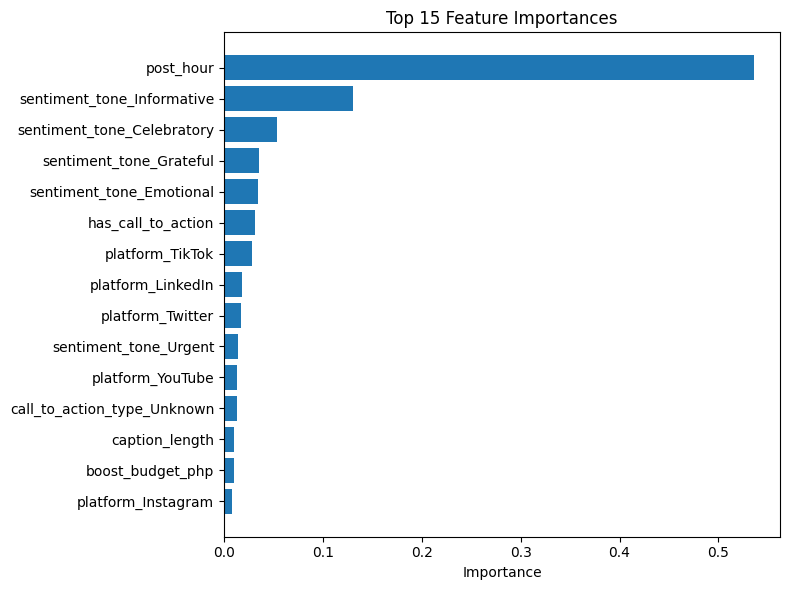

Top 15 feature importances - Classification (Random Forest)


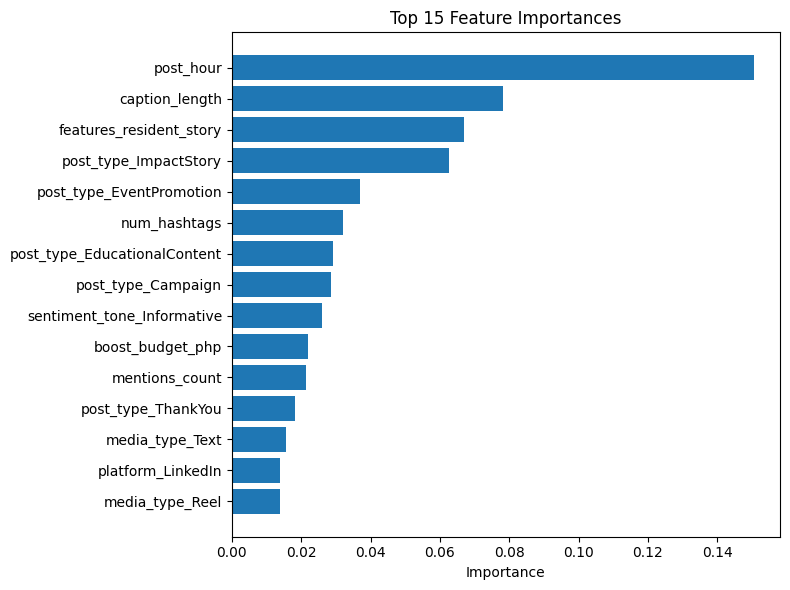


Top 15 regression features:
                    feature  importance
                  post_hour    0.535532
 sentiment_tone_Informative    0.130737
 sentiment_tone_Celebratory    0.053612
    sentiment_tone_Grateful    0.034922
   sentiment_tone_Emotional    0.034174
         has_call_to_action    0.031558
            platform_TikTok    0.028133
          platform_LinkedIn    0.017626
           platform_Twitter    0.017442
      sentiment_tone_Urgent    0.014521
           platform_YouTube    0.013441
call_to_action_type_Unknown    0.013142
             caption_length    0.010159
           boost_budget_php    0.009549
         platform_Instagram    0.008084

Top 15 classification features:
                     feature  importance
                   post_hour    0.150537
              caption_length    0.078215
     features_resident_story    0.066802
       post_type_ImpactStory    0.062504
    post_type_EventPromotion    0.037029
                num_hashtags    0.031991
post_type_E

In [16]:
from utils.evaluation import plot_feature_importance

print(f"Top 15 feature importances - Regression ({best_reg_model_name})")
plot_feature_importance(best_reg_model, X.columns, top_n=15)

print(f"Top 15 feature importances - Classification ({best_clf_model_name})")
plot_feature_importance(best_clf_model, X.columns, top_n=15)

reg_importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": best_reg_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

clf_importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": best_clf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

print("\nTop 15 regression features:")
print(reg_importance_df.head(15).to_string(index=False))
print("\nTop 15 classification features:")
print(clf_importance_df.head(15).to_string(index=False))

### Detailed Findings
**What drives engagement rate:** Post timing is the single biggest lever — when you post matters more than what you post for raw engagement. Among controllable content factors, informative and celebratory tones outperform urgent or emotional tones. TikTok and LinkedIn generate higher engagement than other platforms. Always include a call to action.

**What drives donation referrals:** Content featuring real resident stories is the second strongest predictor of donation conversion after timing. Impact Story and Event Promotion post types convert significantly better than general content. Longer captions correlate with higher donation conversion — donors want context and narrative, not just a short caption.

**The strategic gap:** Engagement and donations are driven by different content strategies. The organization should not use likes or comments as a proxy for fundraising success. A post can go viral and generate zero donations. Resident story posts may get fewer likes but convert to donations at a much higher rate.

**Recommended actions:**
- Schedule donation-focused posts (impact stories, resident stories) during peak hours identified by the model
- Reserve shorter punchy posts for engagement and awareness
- Prioritize TikTok and LinkedIn for reach, but use longer narrative captions on donation-focused posts
- Never post a fundraising appeal without a resident story or impact framing

## Section 10: Save Model

In [17]:
import joblib

joblib.dump(best_reg_model, "../../saved_models/social_engagement_regression.pkl")
print("Saved regression model to ../../saved_models/social_engagement_regression.pkl")

joblib.dump(best_clf_model, "../../saved_models/social_engagement_classifier.pkl")
print("Saved classifier model to ../../saved_models/social_engagement_classifier.pkl")

joblib.dump(list(X.columns), "../../saved_models/social_engagement_features.pkl")
print("Saved feature names to ../../saved_models/social_engagement_features.pkl")

Saved regression model to ../../saved_models/social_engagement_regression.pkl
Saved classifier model to ../../saved_models/social_engagement_classifier.pkl
Saved feature names to ../../saved_models/social_engagement_features.pkl
